# **🎓 Student Grade Prediction — ML Project**
**Target:** G3 (Final Grade) | **Models :** Linear Regression · ElasticNet ·  Ridge · Lasso · SVR · Random Forest

## **Import Libiraries**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## **📂 Load Data**

In [3]:
df = pd.read_csv('student_data.csv')
pd.set_option('display.max_columns', None)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## **🔧 Preprocessing**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [6]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,2,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,1,0,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10


In [7]:
df.describe()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,0.116456,0.473418,16.696203,0.777215,0.288608,0.896203,2.749367,2.521519,2.169620,2.281013,1.255696,0.853165,1.448101,2.035443,0.334177,0.129114,0.612658,0.458228,0.508861,0.794937,0.949367,0.832911,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,0.321177,0.499926,1.276043,0.416643,0.453690,0.305384,1.094735,1.088201,1.227473,0.863542,1.208236,0.536684,0.697505,0.839240,0.743651,0.335751,0.487761,0.498884,0.500555,0.404260,0.219525,0.373528,0.472300,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,0.000000,0.000000,16.000000,1.000000,0.000000,1.000000,2.000000,2.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,0.000000,0.000000,17.000000,1.000000,0.000000,1.000000,3.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,0.000000,1.000000,18.000000,1.000000,1.000000,1.000000,4.000000,3.000000,3.000000,3.000000,3.000000,1.000000,2.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,1.000000,1.000000,22.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000,4.000000,3.000000,2.000000,4.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## **🔍 EDA**

**G3 Distribution**

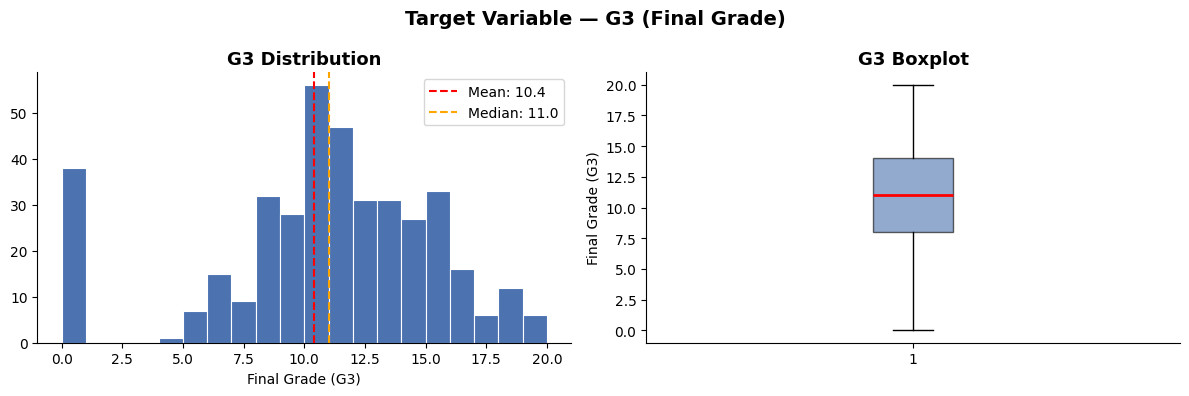

Mean   : 10.42
Median : 11.00
Std    : 4.58
Min    : 0
Max    : 20


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['G3'], bins=20, color='#4C72B0', edgecolor='white', linewidth=0.8)
axes[0].axvline(df['G3'].mean(), color='red', linestyle='--', label=f"Mean: {df['G3'].mean():.1f}")
axes[0].axvline(df['G3'].median(), color='orange', linestyle='--', label=f"Median: {df['G3'].median():.1f}")
axes[0].set_title('G3 Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Final Grade (G3)')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].boxplot(df['G3'], patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('G3 Boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Final Grade (G3)')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Target Variable — G3 (Final Grade)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean   : {df['G3'].mean():.2f}")
print(f"Median : {df['G3'].median():.2f}")
print(f"Std    : {df['G3'].std():.2f}")
print(f"Min    : {df['G3'].min()}")
print(f"Max    : {df['G3'].max()}")

**G3 Class Balance Check**

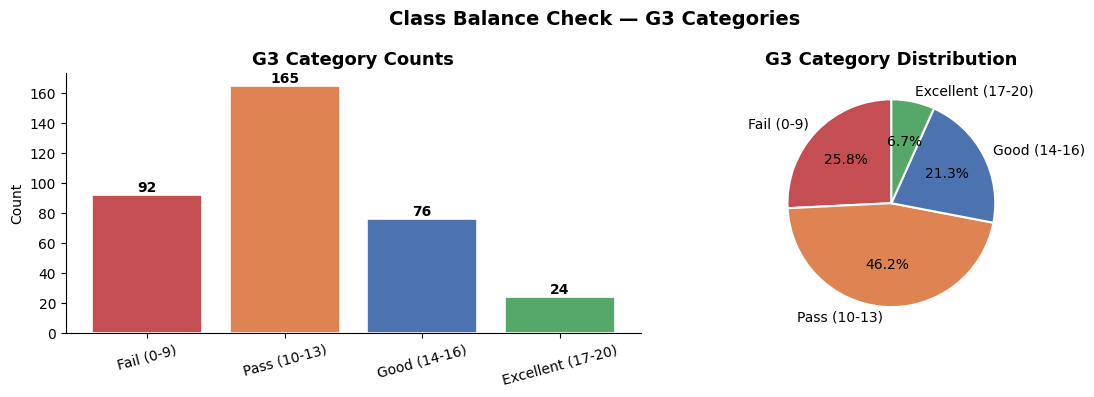

G3_cat
Fail (0-9)            92
Pass (10-13)         165
Good (14-16)          76
Excellent (17-20)     24
Name: count, dtype: int64


In [9]:
bins   = [0, 9, 13, 16, 20]
labels = ['Fail (0-9)', 'Pass (10-13)', 'Good (14-16)', 'Excellent (17-20)']
df['G3_cat'] = pd.cut(df['G3'], bins=bins, labels=labels)

colors_cat = ['#C44E52', '#DD8452', '#4C72B0', '#55A868']
counts = df['G3_cat'].value_counts().reindex(labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, counts.values, color=colors_cat, edgecolor='white', linewidth=1.2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].set_title('G3 Category Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
axes[0].spines[['top','right']].set_visible(False)

axes[1].pie(counts.values, labels=labels, colors=colors_cat,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('G3 Category Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Class Balance Check — G3 Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(counts)
df.drop(columns=['G3_cat'], inplace=True)

**Grade Distributions — G1, G2, G3**

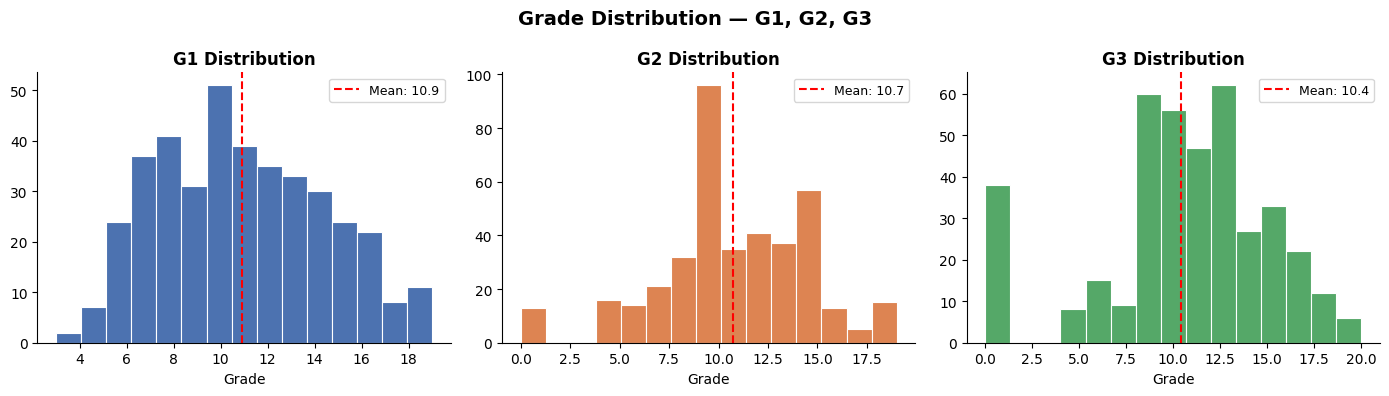

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_g = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, color in zip(axes, ['G1', 'G2', 'G3'], colors_g):
    ax.hist(df[col], bins=15, color=color, edgecolor='white', linewidth=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Grade')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Grade Distribution — G1, G2, G3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Failures vs G3**

/tmp/ipykernel_4326/1267802921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='failures', y='G3', data=df, palette='coolwarm')


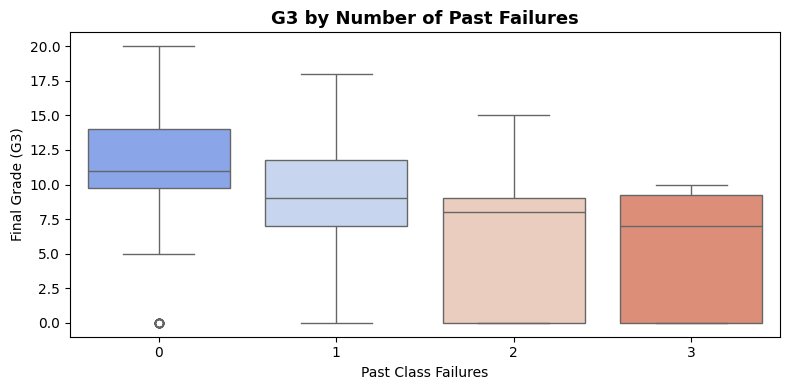

In [11]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='failures', y='G3', data=df, palette='coolwarm')
plt.title('G3 by Number of Past Failures', fontsize=13, fontweight='bold')
plt.xlabel('Past Class Failures')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()

**Study Time vs G3**

/tmp/ipykernel_4326/1610887246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='Blues')


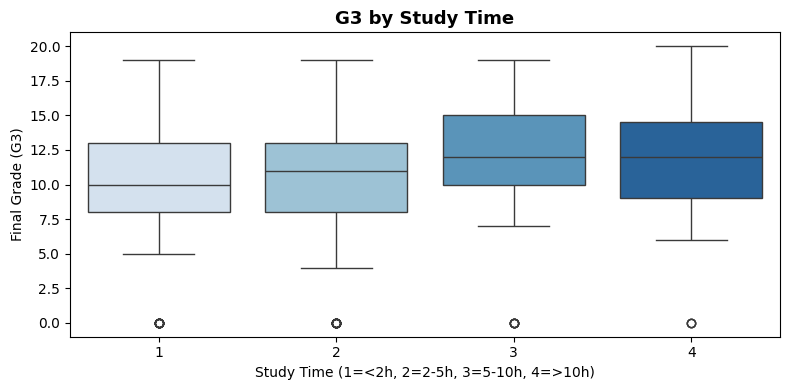

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='studytime', y='G3', data=df, palette='Blues')
plt.title('G3 by Study Time', fontsize=13, fontweight='bold')
plt.xlabel('Study Time (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()

**Absences vs G3**

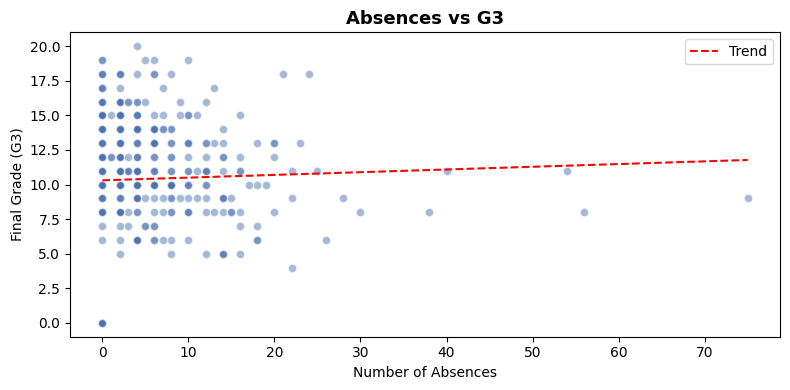

In [13]:
plt.figure(figsize=(8, 4))
plt.scatter(df['absences'], df['G3'], alpha=0.5, color='#4C72B0', edgecolors='white')
z = np.polyfit(df['absences'], df['G3'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['absences']), p(sorted(df['absences'])), 'r--', lw=1.5, label='Trend')
plt.title('Absences vs G3', fontsize=13, fontweight='bold')
plt.xlabel('Number of Absences')
plt.ylabel('Final Grade (G3)')
plt.legend()
plt.tight_layout()
plt.show()

**Higher Education Aspiration vs G3**

/tmp/ipykernel_4326/4043220599.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='higher', y='G3', data=df, palette=['#C44E52', '#55A868'])


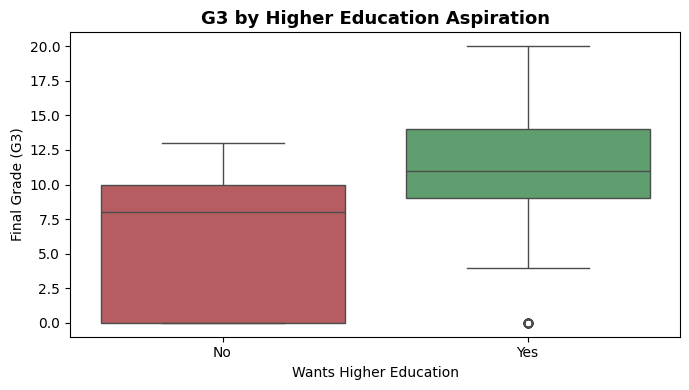

In [14]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='higher', y='G3', data=df, palette=['#C44E52', '#55A868'])
plt.xticks([0, 1], ['No', 'Yes'])
plt.title('G3 by Higher Education Aspiration', fontsize=13, fontweight='bold')
plt.xlabel('Wants Higher Education')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()

**Alcohol Consumption vs G3**

/tmp/ipykernel_4326/2350824391.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dalc', y='G3', data=df, palette='Reds', ax=axes[0])
/tmp/ipykernel_4326/2350824391.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Walc', y='G3', data=df, palette='Oranges', ax=axes[1])


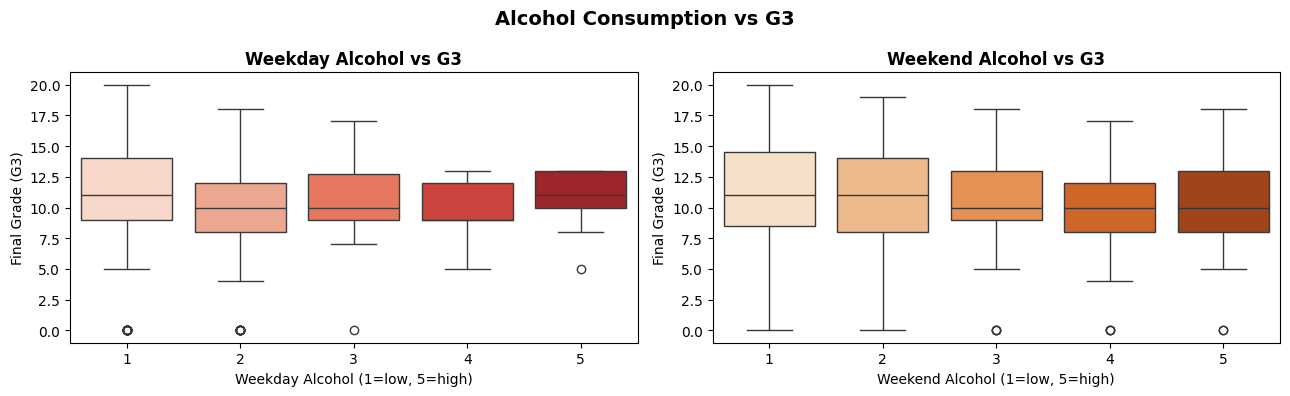

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x='Dalc', y='G3', data=df, palette='Reds', ax=axes[0])
axes[0].set_title('Weekday Alcohol vs G3', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Weekday Alcohol (1=low, 5=high)')
axes[0].set_ylabel('Final Grade (G3)')

sns.boxplot(x='Walc', y='G3', data=df, palette='Oranges', ax=axes[1])
axes[1].set_title('Weekend Alcohol vs G3', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Weekend Alcohol (1=low, 5=high)')
axes[1].set_ylabel('Final Grade (G3)')

plt.suptitle('Alcohol Consumption vs G3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Pairplot — Key Features**

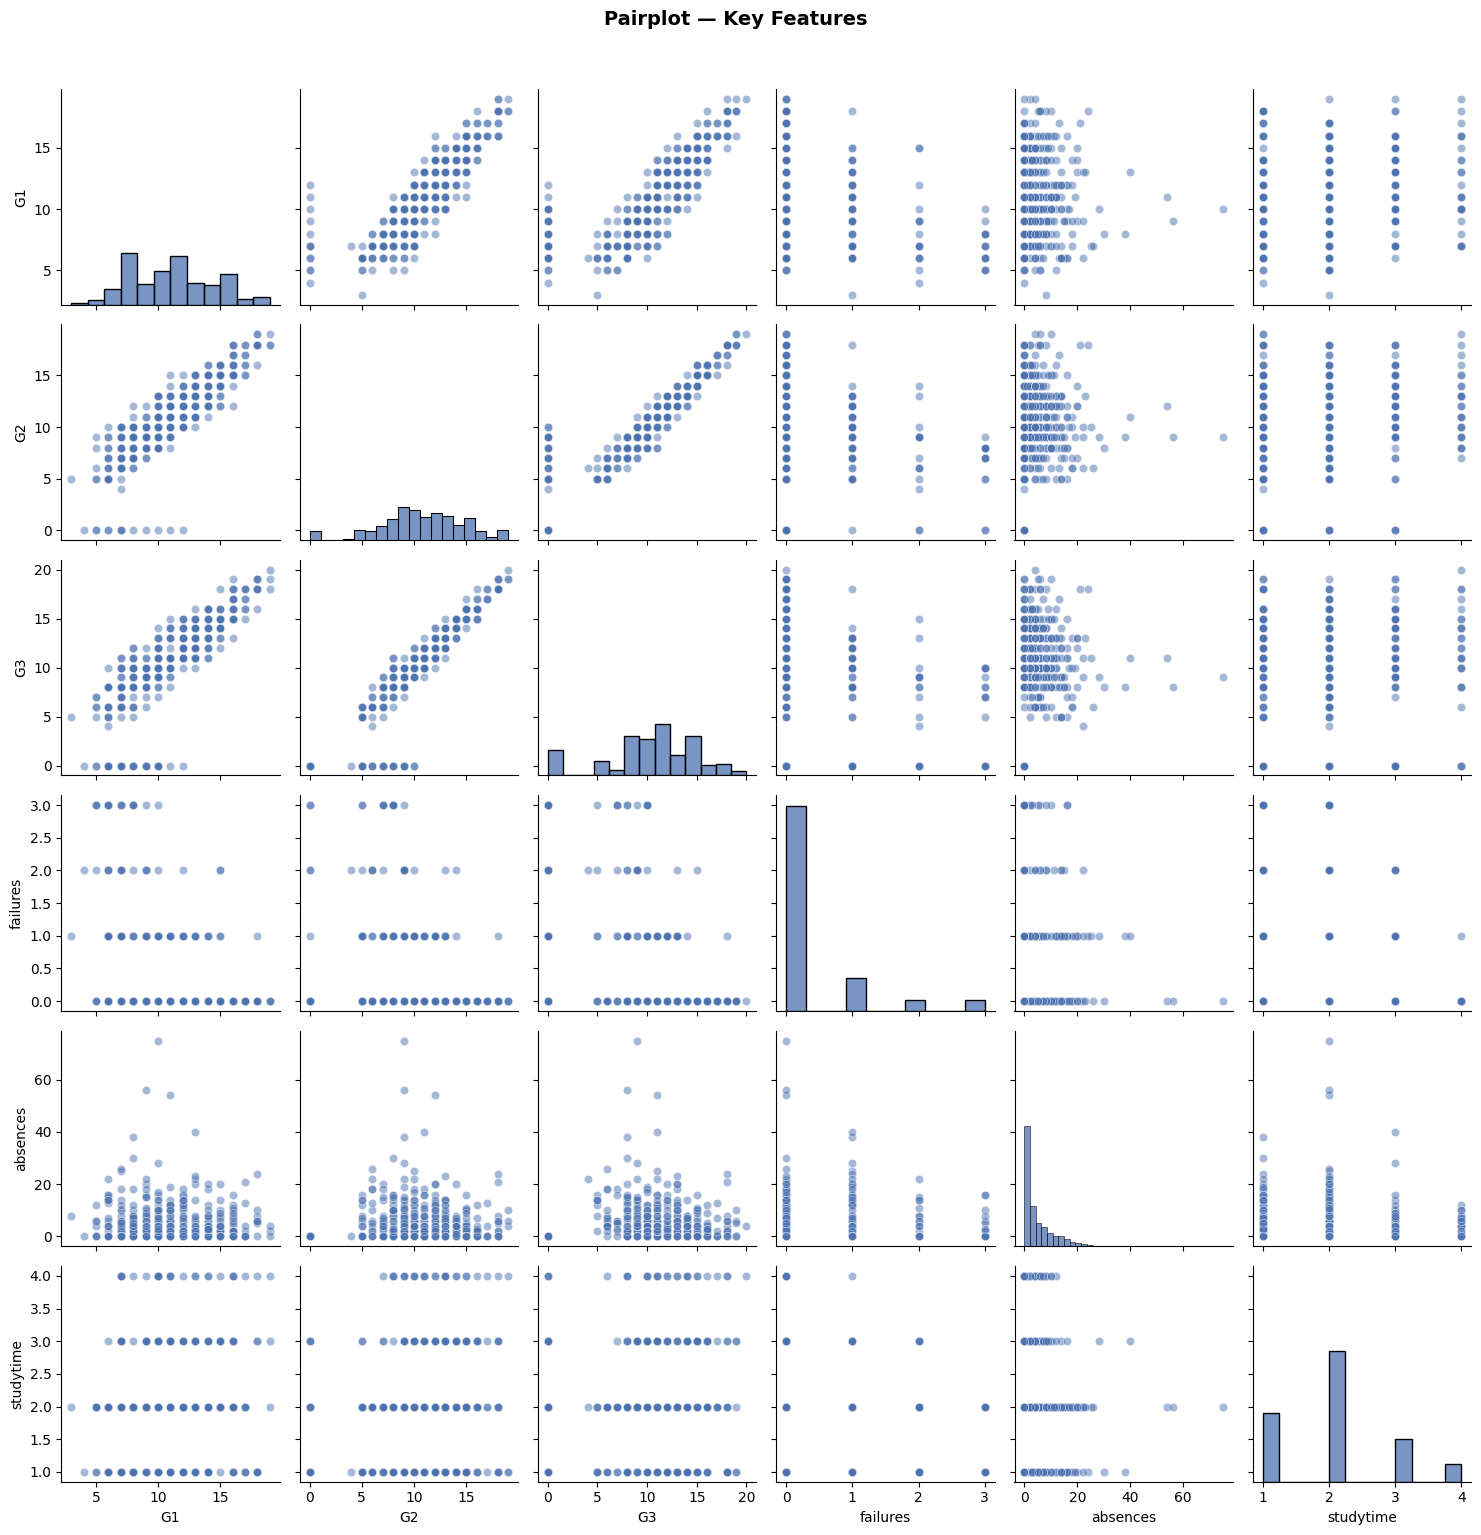

In [95]:
pairplot_cols = ['G1', 'G2', 'G3', 'failures', 'absences', 'studytime']
sns.pairplot(df[pairplot_cols], diag_kind='hist',
             plot_kws={'alpha': 0.5, 'color': '#4C72B0'},
             diag_kws={'color': '#4C72B0'})
plt.suptitle('Pairplot — Key Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Correlation Heatmap**

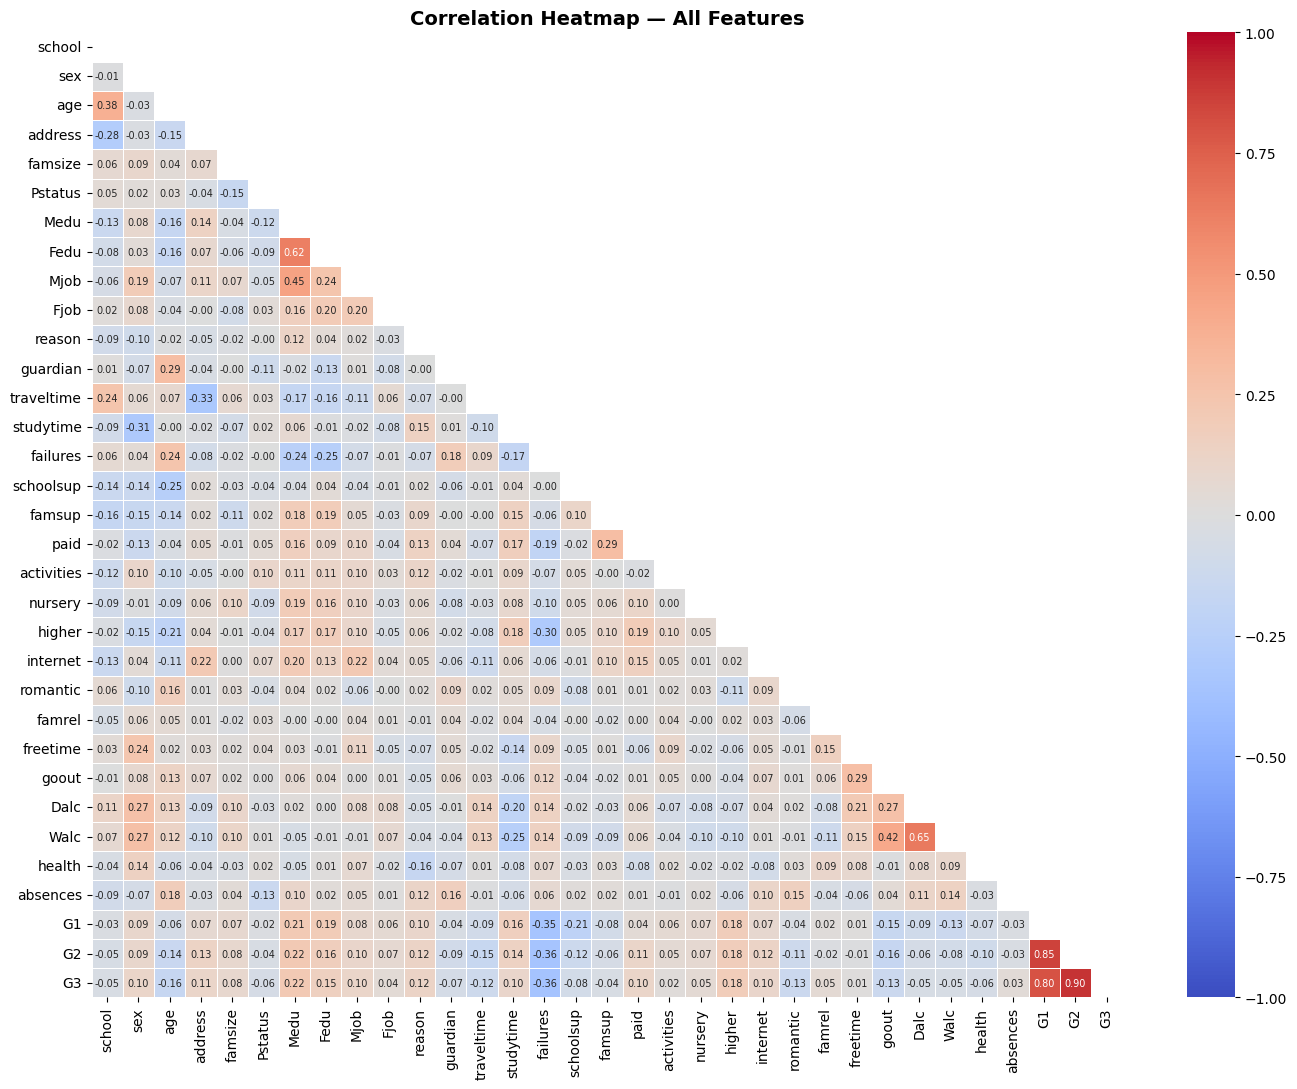

In [96]:
plt.figure(figsize=(14, 11))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

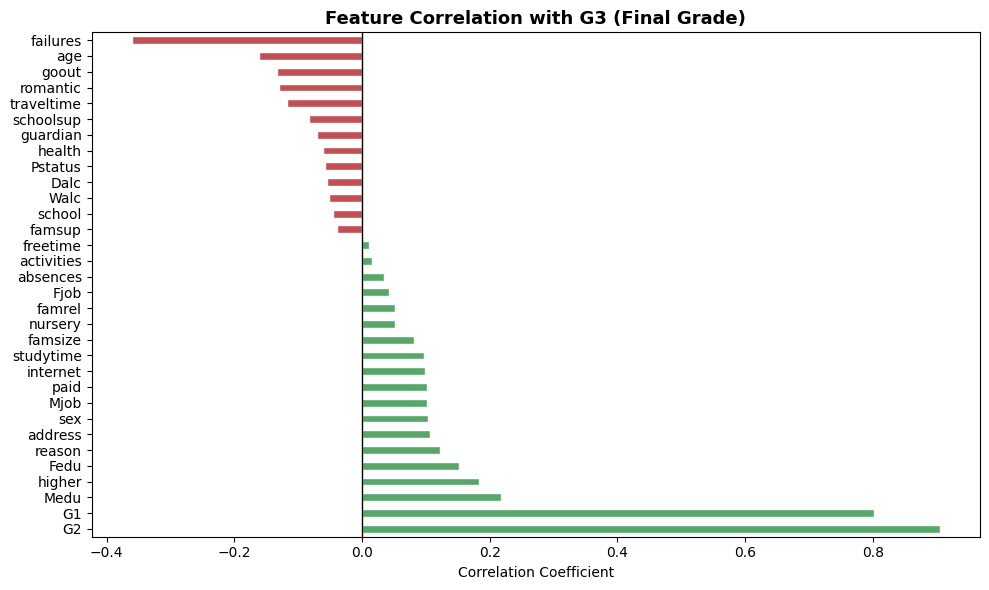

Top Positive Correlations with G3:
G2        0.904868
G1        0.801468
Medu      0.217147
higher    0.182465
Fedu      0.152457
Name: G3, dtype: float64

Top Negative Correlations with G3:
traveltime   -0.117142
romantic     -0.129970
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


In [97]:
g3_corr = df.corr()['G3'].drop('G3').sort_values(ascending=False)
colors_corr = ['#55A868' if v > 0 else '#C44E52' for v in g3_corr.values]

plt.figure(figsize=(10, 6))
g3_corr.plot(kind='barh', color=colors_corr, edgecolor='white')
plt.axvline(0, color='black', lw=1)
plt.title('Feature Correlation with G3 (Final Grade)', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print('Top Positive Correlations with G3:')
print(g3_corr.head(5))
print('\nTop Negative Correlations with G3:')
print(g3_corr.tail(5))

**🧹 Outlier Detection & Treatment**

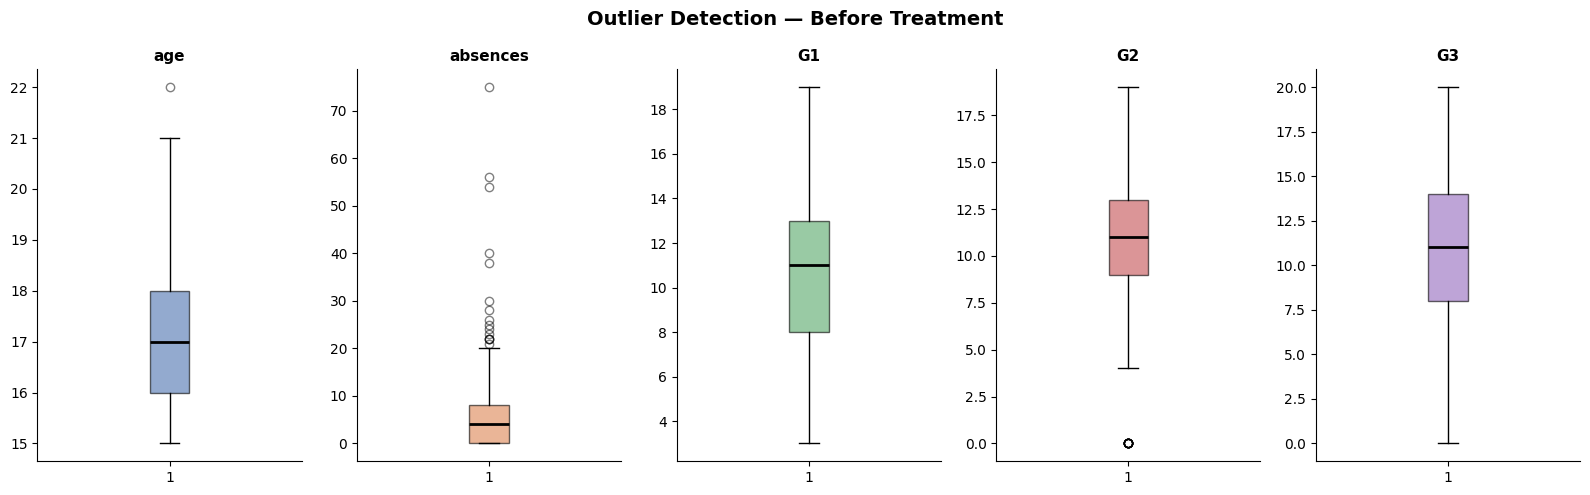

In [16]:
outlier_cols = ['age', 'absences', 'G1', 'G2', 'G3']
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 5))
colors_out = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9467BD']

for ax, col, color in zip(axes, outlier_cols, colors_out):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', color=color, alpha=0.5))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Outlier Detection — Before Treatment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
Q1 = df['absences'].quantile(0.25)
Q3 = df['absences'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

print(f"Absences — Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper bound: {upper}")
print(f"Outliers found: {(df['absences'] > upper).sum()}")

df['absences'] = df['absences'].clip(upper=upper)

print(f"\nAfter capping — Max absences: {df['absences'].max()}")

Absences — Q1: 0.0, Q3: 8.0, IQR: 8.0, Upper bound: 20.0
Outliers found: 15

After capping — Max absences: 20


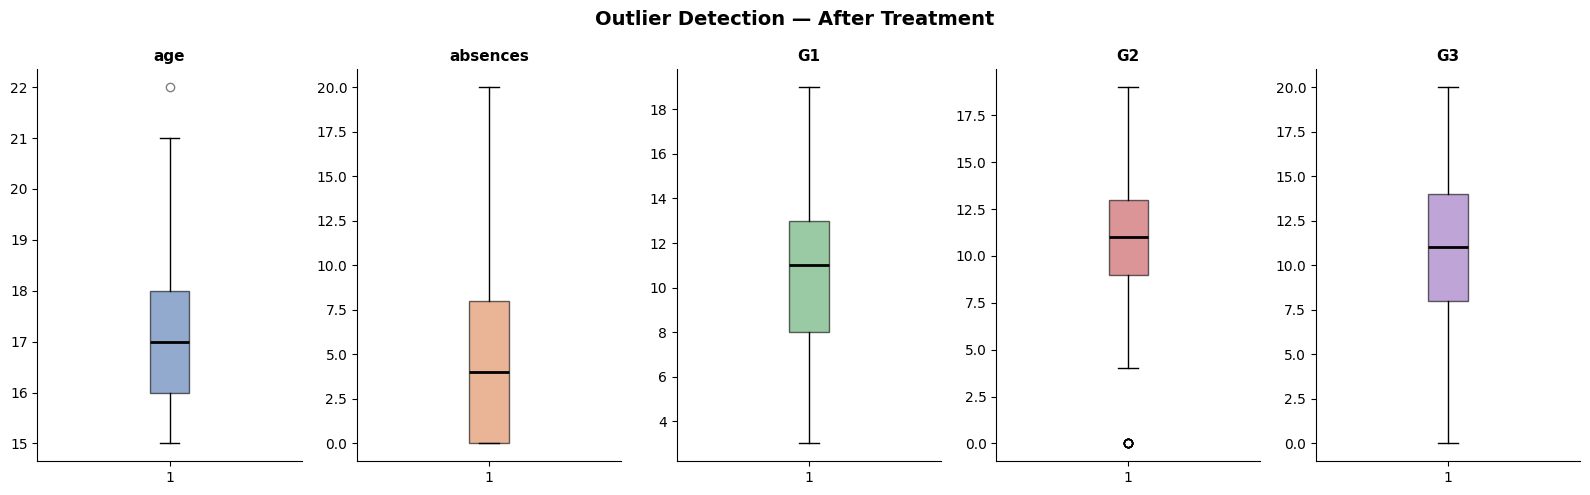

In [18]:
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 5))

for ax, col, color in zip(axes, outlier_cols, colors_out):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', color=color, alpha=0.5))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Outlier Detection — After Treatment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **🎯 Feature Selection**

In [19]:
X = df.drop(columns=['G3', 'school', 'reason', 'guardian', 'nursery', 'Pstatus', 'sex', 'age'])
y = df['G3']

print(f"Features: {X.shape[1]}")
print(X.columns.tolist())

Features: 25
['address', 'famsize', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


## **✂️ Data Splitting & Scaling**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train Size: {X_train.shape[0]}")
print(f"Test Size : {X_test.shape[0]}")

Train Size: 316
Test Size : 79


## **🤖 Models**

## **🔵 ElasticNet Regression**

In [61]:
en = ElasticNet(alpha=0.5, l1_ratio=0.999)
en.fit(X_train_sc, y_train)

ElasticNet(alpha=0.5, l1_ratio=0.999)

In [62]:
en_pred = en.predict(X_test_sc)

en_rmse = np.sqrt(mean_squared_error(y_test, en_pred))
en_mae  = mean_absolute_error(y_test, en_pred)
en_r2   = r2_score(y_test, en_pred)

print('── ElasticNet ──')
print(f'RMSE : {en_rmse:.3f}')
print(f'MAE  : {en_mae:.3f}')
print(f'R²   : {en_r2:.3f}')

── ElasticNet ──
RMSE : 2.063
MAE  : 1.202
R²   : 0.792


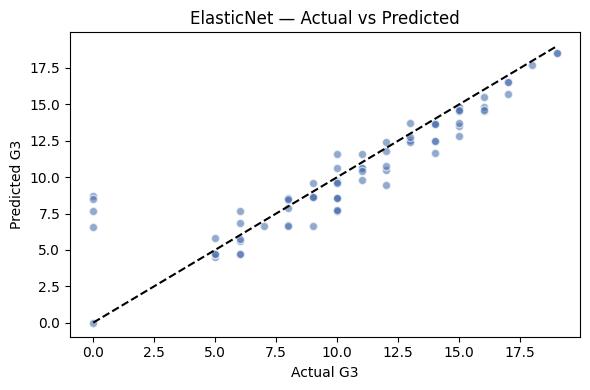

In [63]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, en_pred, alpha=0.6, color='#4C72B0', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('ElasticNet — Actual vs Predicted')
plt.tight_layout()
plt.show()

## **🔵 Ridge Regression**

In [93]:
ridge = Ridge(alpha=30)
ridge.fit(X_train_sc, y_train)

Ridge(alpha=30)

In [94]:
ridge_pred = ridge.predict(X_test_sc)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae  = mean_absolute_error(y_test, ridge_pred)
ridge_r2   = r2_score(y_test, ridge_pred)

print('── Ridge Regression ──')
print(f'RMSE : {ridge_rmse:.3f}')
print(f'MAE  : {ridge_mae:.3f}')
print(f'R²   : {ridge_r2:.3f}')

── Ridge Regression ──
RMSE : 2.235
MAE  : 1.526
R²   : 0.756


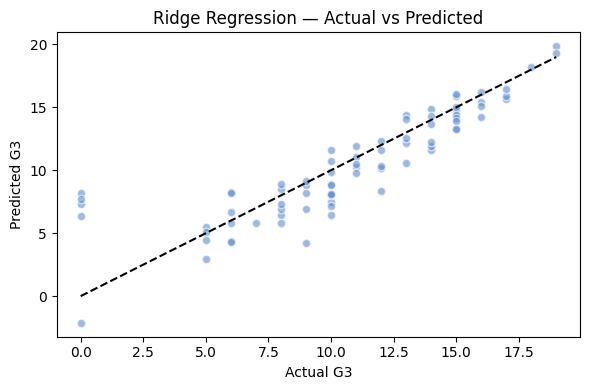

In [95]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, ridge_pred, alpha=0.6, color='#5C8DD6', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Ridge Regression — Actual vs Predicted')
plt.tight_layout()
plt.show()

## **🔵 Lasso Regression**

In [102]:
lasso = Lasso(alpha=0.5)
lasso.fit(X_train_sc, y_train)

Lasso(alpha=0.5)

In [103]:
lasso_pred = lasso.predict(X_test_sc)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae  = mean_absolute_error(y_test, lasso_pred)
lasso_r2   = r2_score(y_test, lasso_pred)

print('── Lasso Regression ──')
print(f'RMSE : {lasso_rmse:.3f}')
print(f'MAE  : {lasso_mae:.3f}')
print(f'R²   : {lasso_r2:.3f}')

── Lasso Regression ──
RMSE : 2.063
MAE  : 1.202
R²   : 0.792


In [104]:
lasso_coef = pd.Series(lasso.coef_, index=X.columns)
print(f'\nFeatures شالها Lasso: {(lasso_coef == 0).sum()}')
print(lasso_coef[lasso_coef == 0].index.tolist())


Features شالها Lasso: 23
['address', 'famsize', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


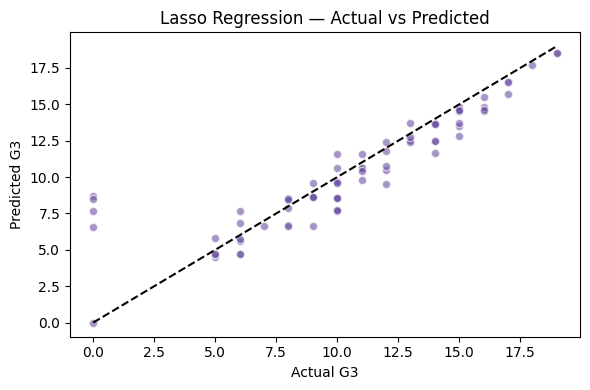

In [105]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, lasso_pred, alpha=0.6, color='#6B4FA0', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Lasso Regression — Actual vs Predicted')
plt.tight_layout()
plt.show()

## **🟢 SVR**

In [126]:
svr = SVR(kernel='linear',
          C=500,
          epsilon=1)

svr.fit(X_train_sc, y_train)

SVR(C=500, epsilon=1, kernel='linear')

In [127]:
svr_pred = svr.predict(X_test_sc)

svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_mae  = mean_absolute_error(y_test, svr_pred)
svr_r2   = r2_score(y_test, svr_pred)

print('── SVR ──')
print(f'RMSE : {svr_rmse:.3f}')
print(f'MAE  : {svr_mae:.3f}')
print(f'R²   : {svr_r2:.3f}')

── SVR ──
RMSE : 2.107
MAE  : 1.252
R²   : 0.784


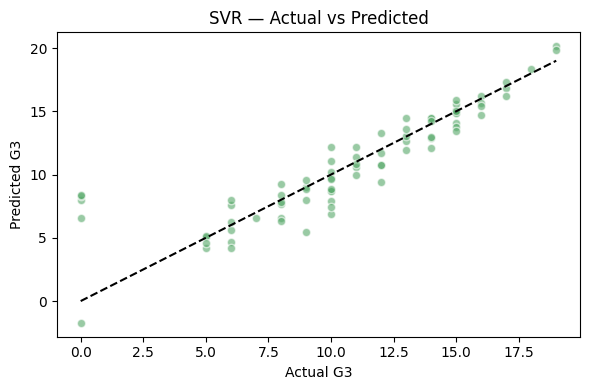

In [128]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, svr_pred, alpha=0.6, color='#55A868', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('SVR — Actual vs Predicted')
plt.tight_layout()
plt.show()

## **🟠 Random Forest**

In [129]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.7,
    max_samples=0.8,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=4, max_features=0.7, max_samples=0.8,
                      min_samples_leaf=10, n_estimators=200, random_state=42)

In [130]:
rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print('── Random Forest ──')
print(f'RMSE : {rf_rmse:.3f}')
print(f'MAE  : {rf_mae:.3f}')
print(f'R²   : {rf_r2:.3f}')

── Random Forest ──
RMSE : 1.781
MAE  : 1.120
R²   : 0.845


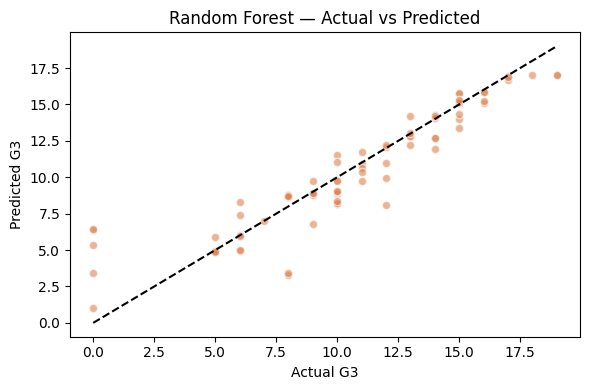

In [131]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, rf_pred, alpha=0.6, color='#DD8452', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Random Forest — Actual vs Predicted')
plt.tight_layout()
plt.show()

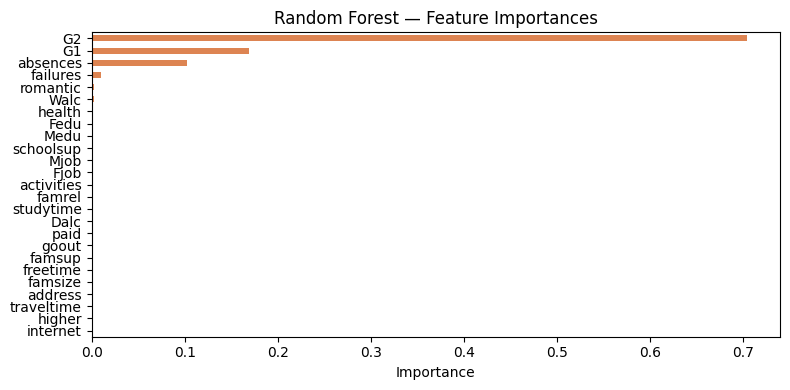

In [132]:
feat_imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
feat_imp_rf[::-1].plot(kind='barh', color='#DD8452')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## **🔍 Overfitting Check**

In [133]:
def overfitting_check(models_dict, y_tr, y_te, title):
    data = []
    for name, (model, X_tr, X_te) in models_dict.items():
        tr_rmse = np.sqrt(mean_squared_error(y_tr, model.predict(X_tr)))
        te_rmse = np.sqrt(mean_squared_error(y_te, model.predict(X_te)))
        diff    = te_rmse - tr_rmse
        status  = '✅ OK' if diff < 0.5 else '⚠️ Overfit'
        data.append([name, round(tr_rmse,3), round(te_rmse,3), round(diff,3), status])
    out = pd.DataFrame(data, columns=['Model','Train RMSE','Test RMSE','Difference','Status'])
    print(f'\n── {title} ──')
    print(out.to_string(index=False))

overfitting_check({
    'ElasticNet': (en,    X_train_sc, X_test_sc),
    'Ridge':             (ridge, X_train_sc, X_test_sc),
    'Lasso':             (lasso, X_train_sc, X_test_sc),
    'SVR':               (svr,   X_train_sc, X_test_sc),
    'Random Forest':     (rf,    X_train,    X_test),
}, y_train, y_test, 'Overfitting Check')


── Overfitting Check ──
        Model  Train RMSE  Test RMSE  Difference Status
   ElasticNet       1.970      2.063       0.093   ✅ OK
        Ridge       1.742      2.235       0.493   ✅ OK
        Lasso       1.969      2.063       0.094   ✅ OK
          SVR       1.771      2.107       0.336   ✅ OK
Random Forest       1.513      1.781       0.268   ✅ OK


## **🏆 Select Best Model**

In [141]:
best_model_name = comparison['RMSE'].idxmin()
print(f"Best Model: {best_model_name} — RMSE: {comparison.loc[best_model_name, 'RMSE']:.3f}")

Best Model: Random Forest — RMSE: 1.781


## **📊 Model Comparison**

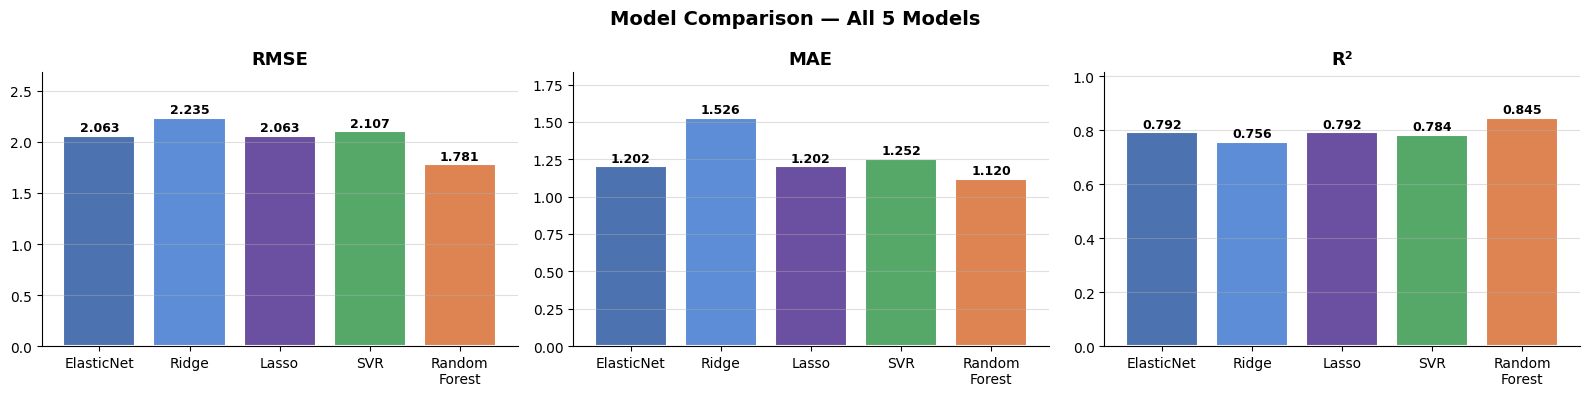

In [134]:
comparison = pd.DataFrame({
    'RMSE': [en_rmse, ridge_rmse, lasso_rmse, svr_rmse, rf_rmse],
    'MAE': [en_mae, ridge_mae, lasso_mae, svr_mae, rf_mae],
    'R²': [en_r2, ridge_r2, lasso_r2, svr_r2, rf_r2]
}, index=['ElasticNet', 'Ridge', 'Lasso', 'SVR', 'Random Forest'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_bar = ['#4C72B0', '#5C8DD6', '#6B4FA0', '#55A868', '#DD8452']
models_names = ['ElasticNet', 'Ridge', 'Lasso', 'SVR', 'Random\nForest']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    vals = comparison[metric].values
    bars = ax.bar(models_names, vals, color=colors_bar, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.2)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Model Comparison — All 5 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **😜 Prediction**

In [147]:
preds_dict = {
    'ElasticNet': en_pred,
    'Ridge':             ridge_pred,
    'Lasso':             lasso_pred,
    'SVR':               svr_pred,
    'Random Forest':     rf_pred,
}

best_pred = preds_dict[best_model_name]

results_df = pd.DataFrame({
    'Actual G3':    y_test.values,
    'Predicted G3': best_pred.round(1),
    'Difference':   (best_pred - y_test.values).round(1)
}).reset_index(drop=True)

results_df.index += 1
print(f"\nActual vs Predicted — {best_model_name} (first 25 students):")

print(results_df.head(25).to_string())


Actual vs Predicted — Random Forest (first 20 students):
    Actual G3  Predicted G3  Difference
1          10           8.2        -1.8
2          12          12.0         0.0
3           5           4.9        -0.1
4          10           9.0        -1.0
5           9           8.9        -0.1
6          13          12.8        -0.2
7          18          17.1        -0.9
8           6           7.4         1.4
9           0           5.3         5.3
10         14          12.7        -1.3
11         15          15.1         0.1
12          7           7.0        -0.0
13         15          14.0        -1.0
14         10          11.5         1.5
15         14          14.3         0.3
16          8           8.8         0.8
17          8           3.3        -4.7
18         11          10.9        -0.1
19         15          15.7         0.7
20          0           6.4         6.4
21         14          14.1         0.1
22         16          15.8        -0.2
23         16         

**── Scatter Plot : Actual vs Predicted Coloured By Error ──**

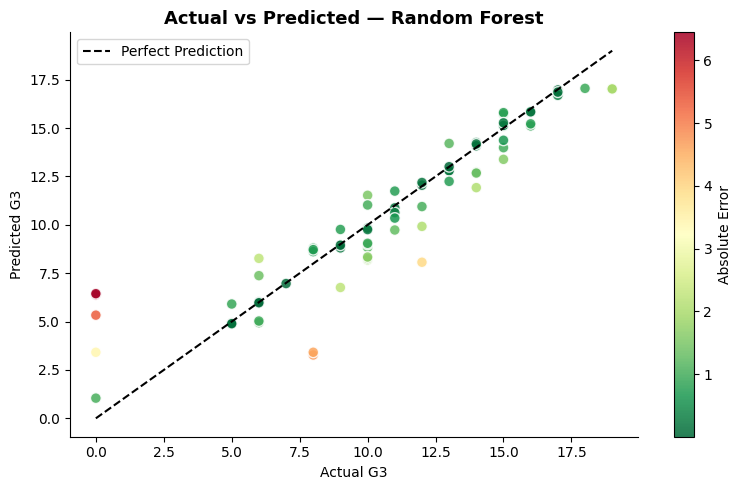

In [148]:
fig, ax = plt.subplots(figsize=(8, 5))
actual = y_test.values
residuals = best_pred - actual
scatter = ax.scatter(actual, best_pred,
                     c=np.abs(residuals), cmap='RdYlGn_r',
                     edgecolors='white', s=60, alpha=0.85)
plt.colorbar(scatter, ax=ax, label='Absolute Error')
ax.plot([actual.min(), actual.max()],
        [actual.min(), actual.max()], 'k--', lw=1.5, label='Perfect Prediction')
ax.set_title(f'Actual vs Predicted — {best_model_name}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Actual G3')
ax.set_ylabel('Predicted G3')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**── Bar Chart : Actual vs Predicted Student Student ──**

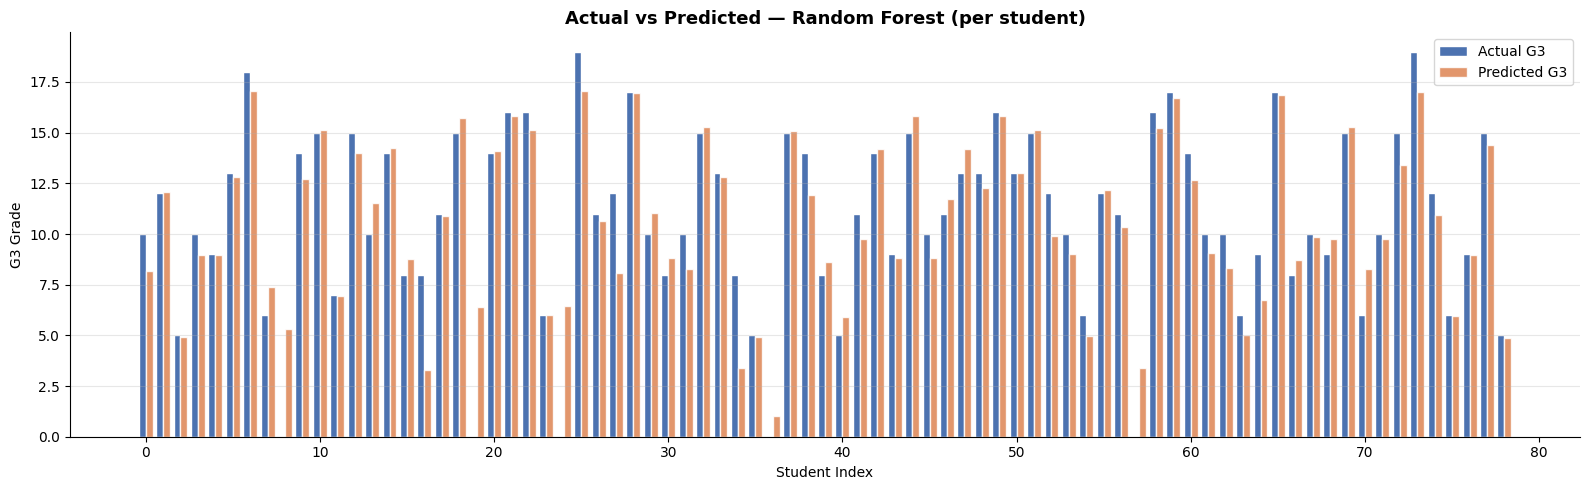

In [149]:
x = np.arange(len(actual))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width/2, actual,    width, label='Actual G3',    color='#4C72B0', edgecolor='white')
ax.bar(x + width/2, best_pred, width, label='Predicted G3', color='#DD8452', edgecolor='white', alpha=0.85)
ax.set_title(f'Actual vs Predicted — {best_model_name} (per student)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Student Index')
ax.set_ylabel('G3 Grade')
ax.legend()
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()